In [1]:
import sys
import os

# Adds the parent directory (root) to the Python path
sys.path.append(os.path.abspath(os.path.join('..')))


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import holidays

In [3]:
df = pd.read_parquet('../data/processed/transactions_with_segments.parquet')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,transaction_type,Segment
0,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,2010-02-15 11:57:00,0.1,13902.0,Denmark,Sale,Mega-Bulk-Tail
1,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,2010-03-17 13:09:00,0.1,13902.0,Denmark,Sale,Mega-Bulk-Tail
2,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,2010-03-17 13:09:00,0.1,13902.0,Denmark,Sale,Mega-Bulk-Tail
3,501534,21085,SET/6 WOODLAND PAPER CUPS,12744,2010-03-17 13:09:00,0.1,13902.0,Denmark,Sale,Mega-Bulk-Tail
4,501534,21092,SET/6 STRAWBERRY PAPER PLATES,12480,2010-03-17 13:09:00,0.1,13902.0,Denmark,Sale,Mega-Bulk-Tail


In [4]:
df.shape

(504731, 10)

In [5]:
retail_df = df[df['Segment'] == "Heavy-Retail"]
print(retail_df.shape[0])
print(retail_df["Quantity"].describe())

185220
count    185220.000000
mean          8.129840
std           3.172308
min           4.000000
25%           6.000000
50%           8.000000
75%          12.000000
max          12.000000
Name: Quantity, dtype: float64


In [6]:
# Convert InvoiceDate to datetime and set it as index for time-series modeling
df = retail_df.copy()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [7]:
print(df['InvoiceDate'].max())
print(df['InvoiceDate'].min()) 

2010-12-09 20:01:00
2009-12-01 07:45:00


## Feature Engineering

### Aggregate Data to Daily Demand

In [8]:
# Convert 'InvoiceDate' to datetime and extract day from timestamp
df['InvoiceDate'] = pd.to_datetime(df["InvoiceDate"]).dt.normalize()

def aggregate_daily_demand(df):

    daily_demand = (
        df.groupby(
            ["InvoiceDate", "StockCode"],
            as_index=False
        )
        .agg(
            Quantity=("Quantity", "sum"),
            Price=("Price", "mean")
        )
    )

    return daily_demand

daily_demand_df = aggregate_daily_demand(df)

In [9]:
daily_demand_df.head()

,InvoiceDate,StockCode,Quantity,Price
0,2009-12-01,10002,12,0.85
1,2009-12-01,10125,4,0.85
2,2009-12-01,10133,6,0.85
3,2009-12-01,10135,16,1.25
4,2009-12-01,15036,7,0.65


In [10]:
daily_demand_df.shape

(125087, 4)

I will use the functions I have already written in features subfolder

In [11]:
from features.calendars import create_calendar_features
from features.easter_christmas import create_christmas_features
from features.holidays import create_holiday_features
from features.lag_features import create_lag_features
from features.momentum import create_momentum_features
from features.rolling import create_rolling_features
from features.sku_features import create_sku_features
from features.create_target import create_target
from features.product_lifecycle import create_product_lifecycle_features
from features.feature_pipeline import build_demand_features

In [12]:
import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "pyyaml"])

0

In [13]:
import pydantic
from config.feature_config import (DATE_COL, 
                                   TARGET_COL, 
                                   PRICE_COL, 
                                   PRODUCT_COL,
                                   DROP_COLS
)

In [14]:
print(DATE_COL)
print(PRICE_COL)

InvoiceDate
Price


In [15]:

demand_features = build_demand_features(daily_demand_df)

In [16]:
demand_features.head()

,InvoiceDate,StockCode,Quantity,Price,price_ratio,day_of_week,day_of_month,week_of_year,month,quarter,...,rolling_mean_28,rolling_std_28,momentum_7_28,momentum_14_28,sku_mean_qty,sku_median_qty,sku_std_qty,sku_avg_price,sku_cv,target
0,2009-12-01,10002,12,0.85,0.934952,1,1,49,12,4,...,NaN,NaN,NaN,NaN,12.973451,12.0,6.555342,0.909137,0.505289,2.564949
1,2009-12-01,10125,4,0.85,1.000000,1,1,49,12,4,...,NaN,NaN,NaN,NaN,5.200000,4.0,1.788854,0.850000,0.344010,1.609438
2,2009-12-01,10133,6,0.85,0.970696,1,1,49,12,4,...,NaN,NaN,NaN,NaN,9.773585,10.0,4.277137,0.875660,0.437622,1.945910
3,2009-12-01,10135,16,1.25,0.972865,1,1,49,12,4,...,NaN,NaN,NaN,NaN,10.391892,10.0,3.947663,1.284865,0.379879,2.833213
4,2009-12-01,15036,7,0.65,0.753728,1,1,49,12,4,...,NaN,NaN,NaN,NaN,17.233871,12.0,9.919275,0.862380,0.575569,2.079442


In [17]:
# Did the item sell at all yesterday?
demand_features["was_active_yesterday"] = (demand_features["lag_1"] > 0).astype(int)

In [18]:
demand_features.shape

(125087, 41)

In [19]:
demand_features['StockCode'].nunique()

3581

In [20]:
demand_features['InvoiceDate'].max()

Timestamp('2010-12-09 00:00:00')

## Build and Train LIGHTGBM Model

In [21]:
# timebased train-valid split
def train_valid_split(
    df,
    date_col,
    split_date
):

    train_df = df[
        df[date_col] < split_date
    ]

    valid_df = df[
        df[date_col] >= split_date
    ]

    return train_df, valid_df

# split the features
train_df, valid_df = train_valid_split(
    demand_features,
    date_col='InvoiceDate',
    split_date='2010-10-01'
)

print(f"Train shape: {train_df.shape}")
print(f"Valid shape: {valid_df.shape}")

Train shape: (91316, 41)
Valid shape: (33771, 41)


In [22]:
import joblib
from lightgbm import LGBMRegressor
import lightgbm as lgb
from sklearn.metrics import (mean_squared_error, 
                             mean_absolute_error, 
                             mean_absolute_percentage_error)

# model parameters
params = {
    'objective': "regression",
    'metric': "rmse",
    #'num_leaves': 31,
    'boosting_type': "gbdt",
    'learning_rate': 0.045,
     'n_estimators': 600,
     'colsample_bytree': 0.8,
     'subsample': 0.8,
     'random_state': 42
}

In [23]:
X_train = train_df.drop(columns = DROP_COLS, errors = "ignore")
y_train = train_df[TARGET_COL]

X_test = valid_df.drop(columns =DROP_COLS, errors = "ignore")
y_test = valid_df[TARGET_COL]   

In [24]:
X_train.columns

Index(['Price', 'price_ratio', 'day_of_week', 'day_of_month', 'week_of_year',
       'month', 'quarter', 'is_weekend', 'days_to_christmas',
       'christmas_window', 'christmas_countdown', 'days_to_easter',
       'easter_window', 'is_holiday', 'holiday_name', 'days_to_next_holiday',
       'days_since_previous_holiday', 'days_since_first_sale', 'lag_1',
       'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_std_7',
       'rolling_mean_14', 'rolling_std_14', 'rolling_mean_28',
       'rolling_std_28', 'momentum_7_28', 'momentum_14_28', 'sku_mean_qty',
       'sku_median_qty', 'sku_std_qty', 'sku_avg_price', 'sku_cv',
       'was_active_yesterday'],
      dtype='str')

In [25]:
# Define your categorical features from your config
categorical_cols = ["holiday_name"]

# create LightGBM datasets
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_cols,)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data,
                        categorical_feature=categorical_cols,)

In [26]:
#Train the model
model = lgb.train(params, train_data, num_boost_round=1000, 
                  valid_sets=[test_data], callbacks=[lgb.early_stopping(stopping_rounds=50)])


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004869 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5345
[LightGBM] [Info] Number of data points in the train set: 91316, number of used features: 34
[LightGBM] [Info] Start training from score 11.646207
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[57]	valid_0's rmse: 8.15157


In [27]:
# make predictions
predictions = model.predict(X_test)

## Evaluation

In [28]:
from models.evaluate import evaluate, wmape_sklearn, weighted_mape

evaluate(y_true = y_test, y_pred = predictions)

{'MAE': 5.539191851725622,
 'RMSE': 8.151574827784662,
 'wmape_sklearn': np.float64(0.4229118203502997),
 'WMAPE': np.float64(0.4229118203502997)}

Evaluation metrics reveal a significant diagnostic pattern: 

- RMSE is extremely high.
- This dramatic gap indicates that while the model is highly accurate on most standard days, it is making a few massive prediction errors on specific outlier days. Because RMSE squares the errors before averaging them, large mistakes penalize this metric severely.

- This mathematical divergence usually happens when the model completely misses unexpected demand spikes, such as promotional events, bulk commercial orders, or the exact peak of a holiday.

## Feature Importance

Plot the feature importance to see what drove these predictions

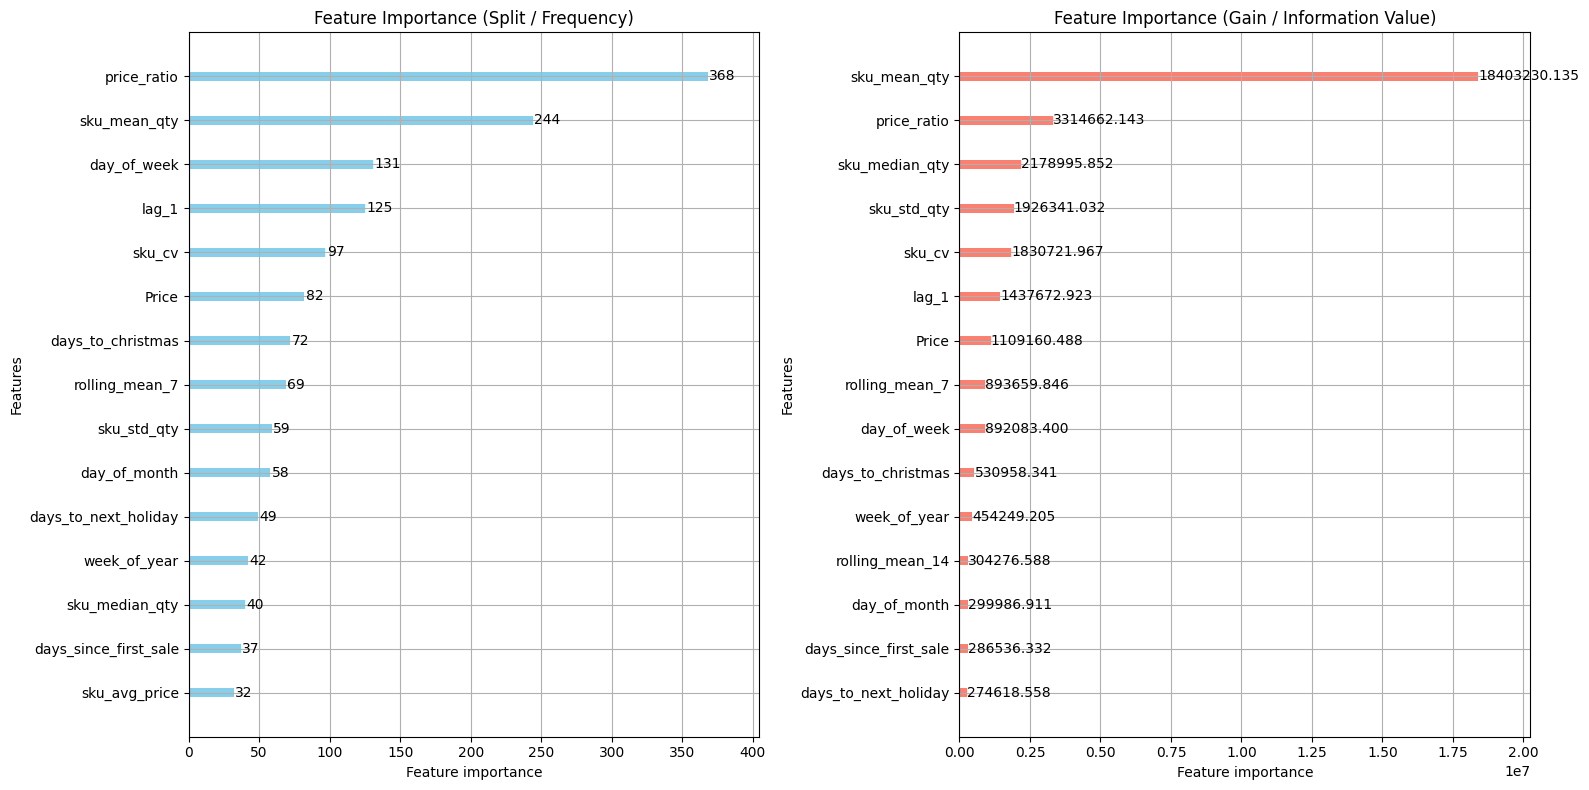

In [29]:
import matplotlib.pyplot as plt

# Configure a side-by-side plotting area
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Plot Split Importance (Frequency of use)
lgb.plot_importance(
    model, 
    importance_type="split", 
    max_num_features=15, 
    ax=ax[0], 
    title="Feature Importance (Split / Frequency)",
    color="skyblue"
)

# Plot Gain Importance (Contribution to accuracy)
lgb.plot_importance(
    model, 
    importance_type="gain", 
    max_num_features=15, 
    ax=ax[1], 
    title="Feature Importance (Gain / Information Value)",
    color="salmon"
)

plt.tight_layout()
plt.show()


## Loss Function Adjustment

By default, LightGBM optimizes for RMSE (objective: 'regression'). I want the model to focus less on penalizing these extreme outliers and instead optimize for overall percentage accuracy. Therefore, I change LightGBM objective parameter

In [30]:
# Update parameters to fix underfitting
params = {
    "objective": "tweedie",  
    "metric": "rmse",
    "tweedie_variance_power": 1.5,  # 1.5 is standard for retail sales
    "learning_rate": 0.03,
    "num_leaves": 63,
}

# Run training with more boosting rounds
model = lgb.train(
    params,
    train_data,
    num_boost_round=2000,
    valid_sets=[test_data],
    callbacks=[lgb.early_stopping(stopping_rounds=150)],
)

# make predictions
predictions = model.predict(X_test)

# evaluate
print("\n")
print("Eval metrics")

evaluate(y_true = y_test, y_pred = predictions)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005087 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5345
[LightGBM] [Info] Number of data points in the train set: 91316, number of used features: 34
[LightGBM] [Info] Start training from score 2.454981
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[140]	valid_0's rmse: 8.09011


Eval metrics


{'MAE': 5.4946576795085,
 'RMSE': 8.090113622696109,
 'wmape_sklearn': np.float64(0.41951168033993536),
 'WMAPE': np.float64(0.41951168033993536)}

In [31]:
# Update training parameters to handle outliers better
params = {
    'objective': "huber",
    'metric': "rmse",
    #'num_leaves': 31,
    #'boosting_type': "gbdt",
    'learning_rate': 0.045,
     'n_estimators': 500,
     #'colsample_bytree': 0.8,
     #'subsample': 0.8,
     'random_state': 42,
     'verbosity': 0
}

#Train the model
model = lgb.train(params, train_data, num_boost_round=1000, 
                  valid_sets=[test_data], callbacks=[lgb.early_stopping(stopping_rounds=50)])

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's rmse: 9.10635


In [32]:
# make predictions
predictions = model.predict(X_test)
evaluate(y_true = y_test, y_pred = predictions)

{'MAE': 5.254534008629901,
 'RMSE': 9.10634636808932,
 'wmape_sklearn': np.float64(0.4011784755189417),
 'WMAPE': np.float64(0.40117847551894176)}

Adjusting objective to Huber loss improved weighted mape 

## Log Transform Target

In [33]:
# log transform target
y_train_log = np.log1p(train_df[TARGET_COL])
y_test_log = valid_df[TARGET_COL] 

# create train data with log target
# create LightGBM datasets
train_data = lgb.Dataset(X_train, label=y_train_log, categorical_feature=categorical_cols,)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data,
                        categorical_feature=categorical_cols,)

In [34]:
# Train model using y_train_log with regression
# model parameters
params1 = {
    'objective': "regression",
    'metric': "rmse",
    #'num_leaves': 31,
    'boosting_type': "gbdt",
    'learning_rate': 0.05,
     'n_estimators': 600,
     'colsample_bytree': 0.8,
     'subsample': 0.8,
     'random_state': 42
}

model = lgb.train(params1, train_data, num_boost_round=1000, 
                  valid_sets=[test_data], 
                  callbacks=[lgb.early_stopping(stopping_rounds=50)])

# Inverse transform predictions before evaluating
log_predictions = model.predict(X_test)
final_predictions = np.expm1(log_predictions)

# evaluate
print("\n")
print("Eval metrics")

evaluate(y_true = y_test, y_pred = final_predictions)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[210]	valid_0's rmse: 14.7571


Eval metrics


{'MAE': 5.250751419454848,
 'RMSE': 8.162740267955172,
 'wmape_sklearn': np.float64(0.4008896785759074),
 'WMAPE': np.float64(0.4008896785759074)}

### Plot feature importance again

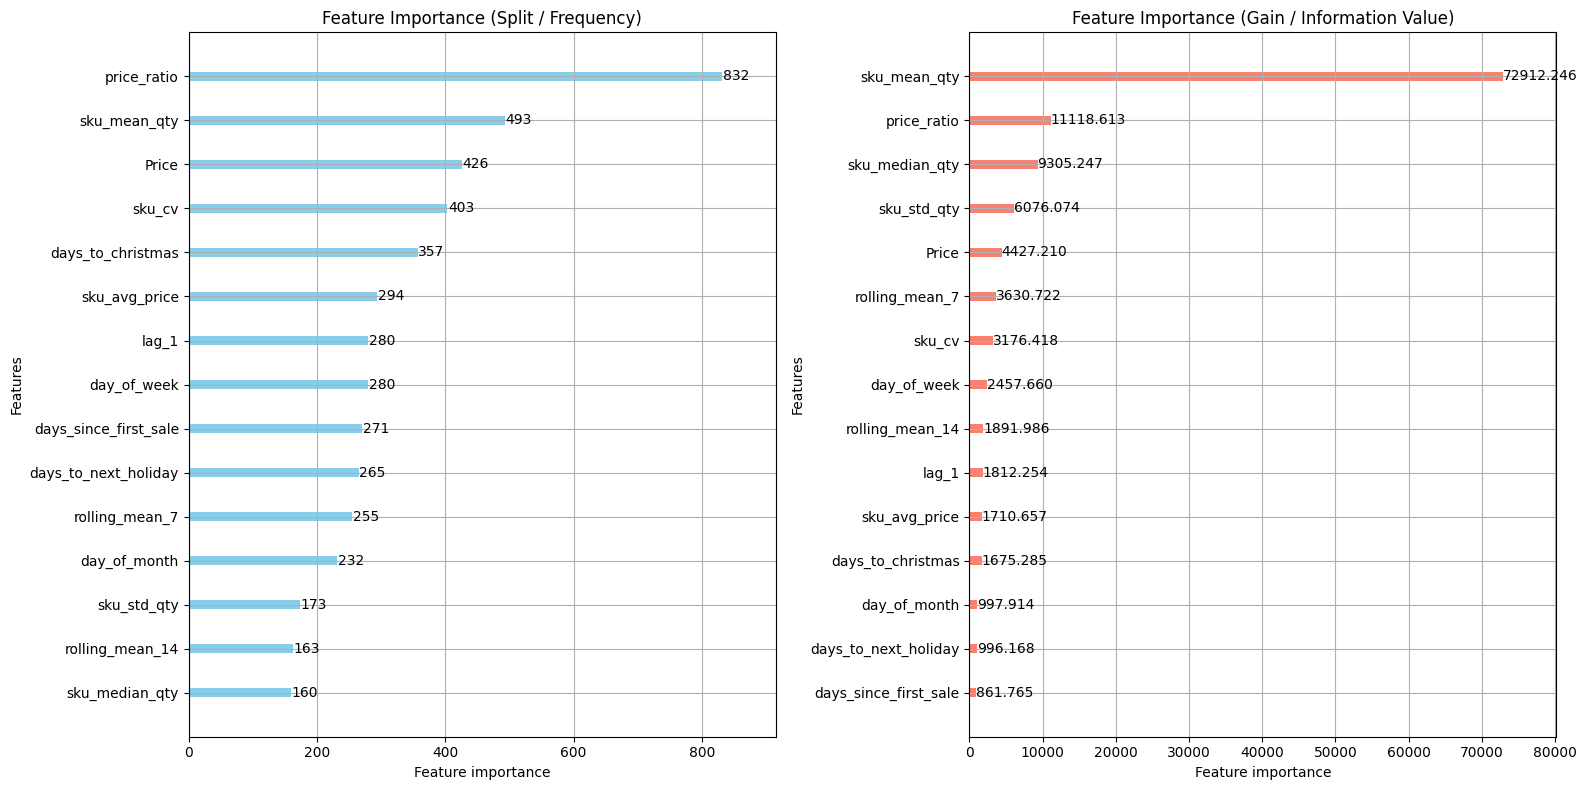

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Plot Split Importance (Frequency of use)
lgb.plot_importance(
    model, 
    importance_type="split", 
    max_num_features=15, 
    ax=ax[0], 
    title="Feature Importance (Split / Frequency)",
    color="skyblue"
)

# Plot Gain Importance (Contribution to accuracy)
lgb.plot_importance(
    model, 
    importance_type="gain", 
    max_num_features=15, 
    ax=ax[1], 
    title="Feature Importance (Gain / Information Value)",
    color="salmon"
)

plt.tight_layout()
plt.show()


### Top features for split

1. Price ratio 
2. SKU mean quantity 
3. Price
4. SKU coefficient of variation 
5. Days to christmass


### Top features for gain

1. SKU mean quantity (72,912)
2. Price ratio (11,118)
3. SKU median quantity (9,305)
4. SKU std quantity (6,076)
5. Price (4,427)
6. Rolling mean 7 (3,630)
7. SKU coefficient of variation (3,176)
8. Day of week (2,457)
9. Rolling mean 14 (1,891)
10. Lag1 (1,812)

In [36]:
# Merge predictions directly back into test_df
test_df = valid_df.copy()
test_df["predicted_demand"] = predictions

# rename target column for clarity during aggregation
test_df = test_df.rename(columns={"Quantity": "actual_demand"})

# verify the alignment side-by-side
print(test_df[["InvoiceDate", "StockCode", "actual_demand", "predicted_demand"]].head())

      InvoiceDate StockCode  actual_demand  predicted_demand
91316  2010-10-01     16236              6          5.726567
91317  2010-10-01     16237              5          7.431843
91318  2010-10-01     17003             10          8.049328
91319  2010-10-01    17164B             10          6.586698
91320  2010-10-01    18097C              6          6.538237


In [37]:
#create weekly timestamp
test_df["week"] = test_df["InvoiceDate"].dt.to_period("W")

# aggregate weekly
weekly_df = (
    test_df.groupby(["week"])[["actual_demand", "predicted_demand"]].sum().reset_index()
)

# Calculate WMAPE on the weekly aggregation
weekly_wmape = weighted_mape(weekly_df["actual_demand"], weekly_df["predicted_demand"])
print(f"Weekly Aggregated Retail WMAPE: {weekly_wmape:.2%}")

Weekly Aggregated Retail WMAPE: 18.99%


In [38]:
# Formula: sum(Forecast - Actual) / sum(Actual) * 100
bias_fo = (test_df['predicted_demand'] - test_df['actual_demand']).sum() / test_df['actual_demand'].sum() * 100
bias_alt = (test_df['predicted_demand'].sum() - test_df['actual_demand'].sum()) / test_df['actual_demand'].sum() * 100

print(f"Model bias: {bias_fo:.2f}%")
print(f"Alt result: {bias_alt:.2f}%")

Model bias: -18.99%
Alt result: -18.99%
